# Notebook 01 — Download Sentinel-2 L2A (T1 pre-fire + T2 post-fire)

Downloads two cloud-free Sentinel-2 L2A scenes over the Gironde fire area (France, 2022):
- **T1 (pre-fire)**: June 2022 — forest intact
- **T2 (post-fire)**: September 2022 — forest destroyed

**Source**: Microsoft Planetary Computer (same Sentinel-2 L2A data as CDSE, HTTPS, no auth required)  
**Fires**: Landiras (~41,000 ha) + La Teste-de-Buch (~14,000 ha), July 2022  
**Environment**: local CPU  
**Runtime**: ~20 min

In [2]:
# === Cell 1: Imports & setup ===
import os, requests, json
from pathlib import Path
from tqdm import tqdm
import numpy as np
import rasterio
import planetary_computer
from pystac_client import Client

BASE   = Path('D:/GeoAI/forest-disturbance')
T1_DIR = BASE / 'data/raw/sentinel2/T1_pre'
T2_DIR = BASE / 'data/raw/sentinel2/T2_post'

# Gironde fire area — Landiras + La Teste-de-Buch fires July 2022
BBOX       = [-1.45, 44.42, -0.42, 45.05]   # [minx, miny, maxx, maxy] WGS84
TARGET_CRS = 'EPSG:32630'                    # UTM zone 30N

# Planetary Computer asset keys for sentinel-2-l2a (no resolution suffix)
BANDS = {'B02': 'B02', 'B03': 'B03', 'B04': 'B04',
         'B8A': 'B8A', 'B11': 'B11', 'B12': 'B12', 'SCL': 'SCL'}

print(f'BBOX      : {BBOX}')
print(f'Target CRS: {TARGET_CRS}')

BBOX      : [-1.45, 44.42, -0.42, 45.05]
Target CRS: EPSG:32630


In [3]:
# === Cell 2: Connect to Planetary Computer STAC ===
# modifier=sign_inplace auto-signs all asset URLs with SAS tokens (no manual auth)
catalog = Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)
print('Planetary Computer catalog connected.')

Planetary Computer catalog connected.


In [4]:
# === Cell 3: STAC search — T1 pre-fire ===
def search_scenes(start, end, max_cloud=10):
    results = catalog.search(
        collections=['sentinel-2-l2a'],
        bbox=BBOX,
        datetime=f'{start}/{end}',
        query={'eo:cloud_cover': {'lt': max_cloud}},
    )
    items = list(results.items())
    items.sort(key=lambda x: x.properties['eo:cloud_cover'])
    return items

# T1: fires started July 12, 2022
t1_items = search_scenes('2022-06-01', '2022-07-10')
print(f'T1 candidates: {len(t1_items)}')
for it in t1_items[:5]:
    print(f'  {it.id}  cloud={it.properties["eo:cloud_cover"]:.2f}%  date={it.datetime.date()}')

T1 candidates: 26
  S2A_MSIL2A_20220709T105041_R051_T30TYR_20221214T210544  cloud=0.00%  date=2022-07-09
  S2A_MSIL2A_20220709T105041_R051_T30TYR_20240708T052543  cloud=0.00%  date=2022-07-09
  S2A_MSIL2A_20220702T105631_R094_T30TYR_20240701T074946  cloud=0.00%  date=2022-07-02
  S2A_MSIL2A_20220702T105631_R094_T30TYR_20220703T010742  cloud=0.00%  date=2022-07-02
  S2A_MSIL2A_20220709T105041_R051_T30TYQ_20221214T231945  cloud=0.00%  date=2022-07-09


In [5]:
# === Cell 4: STAC search — T2 post-fire ===
t2_items = search_scenes('2022-09-01', '2022-09-30')
print(f'T2 candidates: {len(t2_items)}')
for it in t2_items[:5]:
    print(f'  {it.id}  cloud={it.properties["eo:cloud_cover"]:.2f}%  date={it.datetime.date()}')

T2 candidates: 20
  S2B_MSIL2A_20220922T104649_R051_T30TYR_20240730T144438  cloud=0.00%  date=2022-09-22
  S2B_MSIL2A_20220922T104649_R051_T30TYR_20220923T022421  cloud=0.00%  date=2022-09-22
  S2B_MSIL2A_20220922T104649_R051_T30TYQ_20240730T144438  cloud=0.00%  date=2022-09-22
  S2B_MSIL2A_20220922T104649_R051_T30TYQ_20220923T020006  cloud=0.00%  date=2022-09-22
  S2A_MSIL2A_20220920T105741_R094_T30TYR_20240729T125524  cloud=0.00%  date=2022-09-20


In [6]:
# === Cell 5: Select scene that covers the actual fire area ===
# IMPORTANT: the bbox spans two Sentinel-2 tiles; sorting by cloud cover alone
# picks the tile with less cloud, which may NOT be the tile covering the fires.
# Filter by intersection with the fire center point before selecting.
from shapely.geometry import Point, shape

FIRE_CENTER = Point(-0.9, 44.5)   # Landiras fire center, WGS84

def covers_fire(item):
    return shape(item.geometry).contains(FIRE_CENTER)

t1_fire = [it for it in t1_items if covers_fire(it)]
t2_fire = [it for it in t2_items if covers_fire(it)]

print(f'T1 candidates covering fire area: {len(t1_fire)}')
for it in t1_fire[:5]:
    tile = it.properties.get('s2:mgrs_tile', '?')
    print(f'  tile={tile}  cloud={it.properties["eo:cloud_cover"]:.2f}%  date={it.datetime.date()}')

print(f'T2 candidates covering fire area: {len(t2_fire)}')
for it in t2_fire[:5]:
    tile = it.properties.get('s2:mgrs_tile', '?')
    print(f'  tile={tile}  cloud={it.properties["eo:cloud_cover"]:.2f}%  date={it.datetime.date()}')

assert t1_fire, 'No T1 scene covers the fire area — increase max_cloud in search_scenes'
assert t2_fire, 'No T2 scene covers the fire area — increase max_cloud in search_scenes'

T1_SCENE = t1_fire[0]
T2_SCENE = t2_fire[0]

print(f'\nSelected T1: {T1_SCENE.id}')
print(f'            Date={T1_SCENE.datetime.date()}  Cloud={T1_SCENE.properties["eo:cloud_cover"]:.2f}%')
print(f'Selected T2: {T2_SCENE.id}')
print(f'            Date={T2_SCENE.datetime.date()}  Cloud={T2_SCENE.properties["eo:cloud_cover"]:.2f}%')
print(f'Assets: {list(T1_SCENE.assets.keys())}')

T1 candidates covering fire area: 4
  tile=30TXQ  cloud=0.15%  date=2022-07-02
  tile=30TXQ  cloud=0.15%  date=2022-07-02
  tile=30TXQ  cloud=6.55%  date=2022-07-07
  tile=30TXQ  cloud=6.55%  date=2022-07-07
T2 candidates covering fire area: 3
  tile=30TXQ  cloud=0.01%  date=2022-09-20
  tile=30TXQ  cloud=0.01%  date=2022-09-20
  tile=30TXQ  cloud=1.25%  date=2022-09-05

Selected T1: S2A_MSIL2A_20220702T105631_R094_T30TXQ_20220703T002221
            Date=2022-07-02  Cloud=0.15%
Selected T2: S2A_MSIL2A_20220920T105741_R094_T30TXQ_20220920T224439
            Date=2022-09-20  Cloud=0.01%
Assets: ['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP', 'visual', 'preview', 'safe-manifest', 'granule-metadata', 'inspire-metadata', 'product-metadata', 'datastrip-metadata', 'tilejson', 'rendered_preview']


In [7]:
# === Cell 6: Download helpers ===
def download_band(item, asset_key, out_dir):
    if asset_key not in item.assets:
        print(f'  WARNING: {asset_key} not in assets')
        return None
    href     = item.assets[asset_key].href   # already signed by planetary_computer
    filename = f'{item.id}_{asset_key}.tif'
    out_path = out_dir / filename
    if out_path.exists():
        print(f'  Already exists: {filename}')
        return out_path
    resp  = requests.get(href, stream=True, timeout=300)
    resp.raise_for_status()
    total = int(resp.headers.get('content-length', 0))
    with open(out_path, 'wb') as f, tqdm(
            desc=filename[-40:], total=total, unit='B', unit_scale=True, leave=False) as bar:
        for chunk in resp.iter_content(chunk_size=1 << 20):
            f.write(chunk)
            bar.update(len(chunk))
    print(f'  Done: {filename} ({out_path.stat().st_size/1e6:.0f} MB)')
    return out_path

def download_scene(item, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    paths = {}
    for asset_key, band_name in BANDS.items():
        print(f'  [{band_name}]...')
        p = download_band(item, asset_key, out_dir)
        if p: paths[band_name] = p
    return paths

print('Download helpers ready.')

Download helpers ready.


In [8]:
# === Cell 7: Download T1 (pre-fire) ===
print(f'Downloading T1: {T1_SCENE.id}')
t1_paths = download_scene(T1_SCENE, T1_DIR)
print(f'Done: {list(t1_paths.keys())}')

  [B02]...


  Done: S2A_MSIL2A_20220702T105631_R094_T30TXQ_20220703T002221_B02.tif (200 MB)
  [B03]...


  Done: S2A_MSIL2A_20220702T105631_R094_T30TXQ_20220703T002221_B03.tif (205 MB)
  [B04]...


  Done: S2A_MSIL2A_20220702T105631_R094_T30TXQ_20220703T002221_B04.tif (206 MB)
  [B8A]...


  Done: S2A_MSIL2A_20220702T105631_R094_T30TXQ_20220703T002221_B8A.tif (57 MB)
  [B11]...


  Done: S2A_MSIL2A_20220702T105631_R094_T30TXQ_20220703T002221_B11.tif (54 MB)
  [B12]...


  Done: S2A_MSIL2A_20220702T105631_R094_T30TXQ_20220703T002221_B12.tif (53 MB)
  [SCL]...


  Done: S2A_MSIL2A_20220702T105631_R094_T30TXQ_20220703T002221_SCL.tif (1 MB)
Done: ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12', 'SCL']


In [9]:
# === Cell 8: Download T2 (post-fire) ===
print(f'Downloading T2: {T2_SCENE.id}')
t2_paths = download_scene(T2_SCENE, T2_DIR)
print(f'Done: {list(t2_paths.keys())}')

  [B02]...


  Done: S2A_MSIL2A_20220920T105741_R094_T30TXQ_20220920T224439_B02.tif (190 MB)
  [B03]...


  Done: S2A_MSIL2A_20220920T105741_R094_T30TXQ_20220920T224439_B03.tif (192 MB)
  [B04]...


  Done: S2A_MSIL2A_20220920T105741_R094_T30TXQ_20220920T224439_B04.tif (194 MB)
  [B8A]...


  Done: S2A_MSIL2A_20220920T105741_R094_T30TXQ_20220920T224439_B8A.tif (51 MB)
  [B11]...


  Done: S2A_MSIL2A_20220920T105741_R094_T30TXQ_20220920T224439_B11.tif (50 MB)
  [B12]...


  Done: S2A_MSIL2A_20220920T105741_R094_T30TXQ_20220920T224439_B12.tif (50 MB)
  [SCL]...


  Done: S2A_MSIL2A_20220920T105741_R094_T30TXQ_20220920T224439_SCL.tif (2 MB)
Done: ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12', 'SCL']


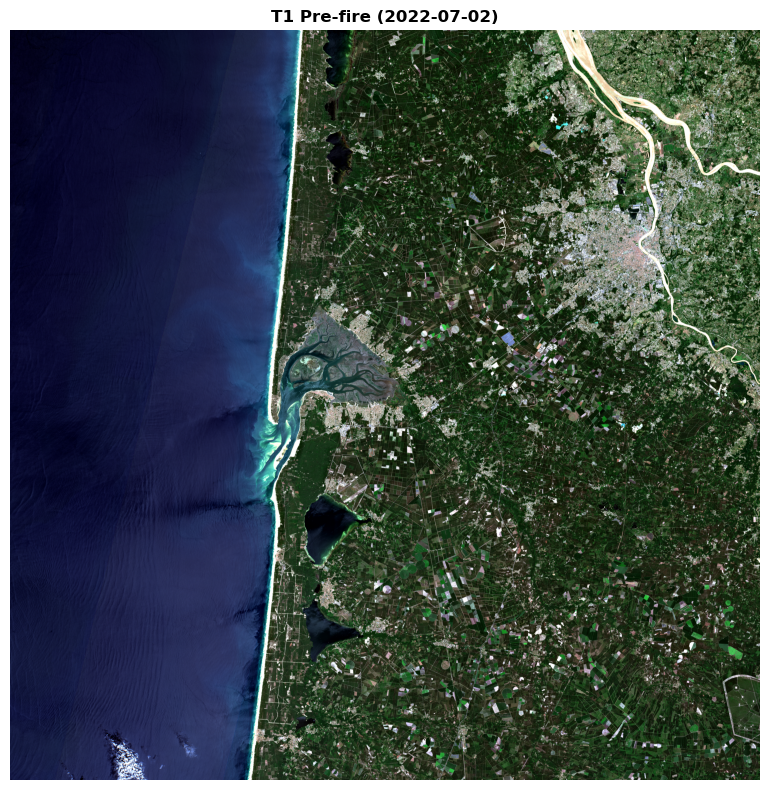

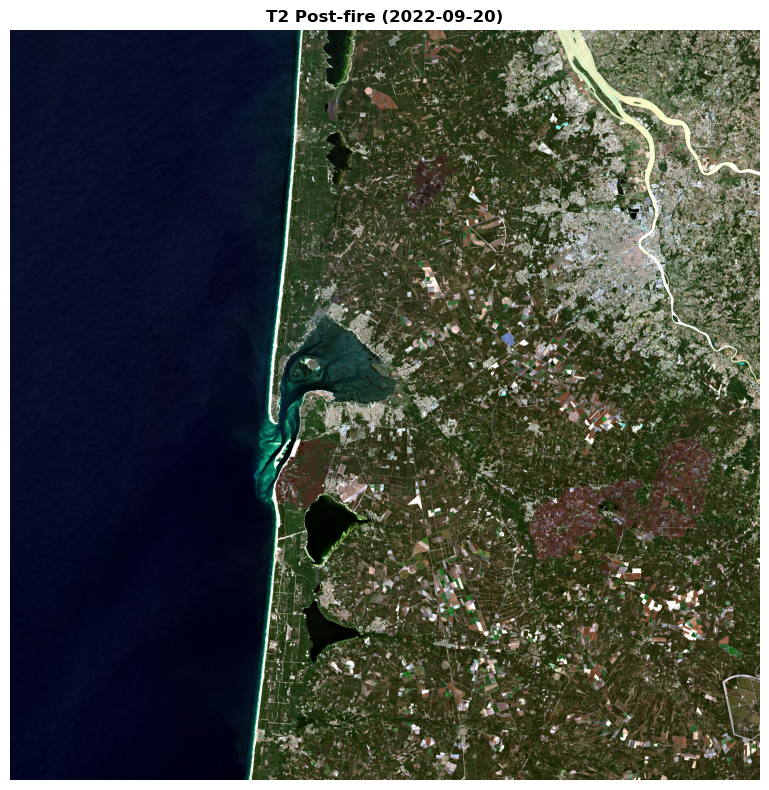

In [10]:
# === Cell 9: Quick visual check (run in VS Code after download completes) ===
import matplotlib.pyplot as plt

def show_rgb(band_paths, title):
    with rasterio.open(band_paths['B04']) as r: red   = r.read(1).astype('float32')
    with rasterio.open(band_paths['B03']) as g: green = g.read(1).astype('float32')
    with rasterio.open(band_paths['B02']) as b: blue  = b.read(1).astype('float32')
    def norm(x):
        v = x[x > 0]
        lo, hi = np.percentile(v, [2, 98])
        return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.dstack([norm(red), norm(green), norm(blue)]))
    plt.title(title, fontsize=12, fontweight='bold')
    plt.axis('off'); plt.tight_layout(); plt.show()

show_rgb(t1_paths, f'T1 Pre-fire ({T1_SCENE.datetime.date()})')
show_rgb(t2_paths, f'T2 Post-fire ({T2_SCENE.datetime.date()})')

In [11]:
# === Cell 10: Save metadata ===
meta = {
    'source': 'Microsoft Planetary Computer',
    'collection': 'sentinel-2-l2a',
    'T1': {'scene_id': T1_SCENE.id, 'date': str(T1_SCENE.datetime.date()),
           'cloud_cover': T1_SCENE.properties['eo:cloud_cover'],
           'band_files': {k: str(v) for k, v in t1_paths.items()}},
    'T2': {'scene_id': T2_SCENE.id, 'date': str(T2_SCENE.datetime.date()),
           'cloud_cover': T2_SCENE.properties['eo:cloud_cover'],
           'band_files': {k: str(v) for k, v in t2_paths.items()}},
    'bbox': BBOX, 'target_crs': TARGET_CRS,
}
meta_path = BASE / 'data/raw/sentinel2/scenes_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Saved: {meta_path}')
print(f'T1: {meta["T1"]["date"]}  cloud={meta["T1"]["cloud_cover"]:.2f}%')
print(f'T2: {meta["T2"]["date"]}  cloud={meta["T2"]["cloud_cover"]:.2f}%')

Saved: D:\GeoAI\forest-disturbance\data\raw\sentinel2\scenes_metadata.json
T1: 2022-07-02  cloud=0.15%
T2: 2022-09-20  cloud=0.01%
